In [1]:
import geopandas as gpd
import pandas as pd

muni = gpd.read_file(r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp")

if "CVEGEO" in muni.columns:
    muni["muni_code"] = muni["CVEGEO"].astype(str).str.zfill(5)
elif {"CVE_ENT","CVE_MUN"}.issubset(muni.columns):
    muni["muni_code"] = (
        muni["CVE_ENT"].astype(str).str.zfill(2)
        + muni["CVE_MUN"].astype(str).str.zfill(3)
    )
else:
    raise ValueError("No municipality code fields found")

# Project to Mexico appropriate CRS (meters)
muni_proj = muni.to_crs(6372)  # Mexico ITRF2008 / LCC (common national projection)

# Compute centroids in projected CRS
muni_proj["centroid"] = muni_proj.geometry.centroid

# Convert centroids back to lat/lon
cent = gpd.GeoDataFrame(
    muni_proj[["muni_code"]],
    geometry=muni_proj["centroid"],
    crs=muni_proj.crs
).to_crs(4326)

centroids = pd.DataFrame({
    "muni_code": cent["muni_code"].values,
    "lat": cent.geometry.y.values,
    "lon": cent.geometry.x.values
})

#centroids.to_csv(r"C:\Users\Tosin\Downloads\BMC\muni_centroids.csv", index=False)

print(centroids.head())
print("Count:", centroids.shape[0])


  muni_code        lat         lon
0     01001  21.811400 -102.295872
1     01002  22.126479 -102.045590
2     01003  21.900640 -102.704911
3     01004  22.360619 -102.297038
4     01005  21.932112 -102.445700
Count: 2469


In [4]:
import geopandas as gpd
import pandas as pd

muni = gpd.read_file(r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp")

if "CVEGEO" in muni.columns:
    muni["muni_code"] = muni["CVEGEO"].astype(str).str.zfill(5)
elif {"CVE_ENT","CVE_MUN"}.issubset(muni.columns):
    muni["muni_code"] = (
        muni["CVE_ENT"].astype(str).str.zfill(2)
        + muni["CVE_MUN"].astype(str).str.zfill(3)
    )
else:
    raise ValueError("No municipality code fields found")

# Project to Mexico appropriate CRS (meters)
muni_proj = muni.to_crs(6372)  # Mexico ITRF2008 / LCC (common national projection)

# Compute centroids in projected CRS
muni_proj["centroid"] = muni_proj.geometry.centroid

# Convert centroids back to lat/lon
cent = gpd.GeoDataFrame(
    muni_proj[["muni_code"]],
    geometry=muni_proj["centroid"],
    crs=muni_proj.crs
).to_crs(4326)

centroids = pd.DataFrame({
    "muni_code": cent["muni_code"].values,
    "lat": cent.geometry.y.values,
    "lon": cent.geometry.x.values
})

#centroids.to_csv(r"C:\Users\Tosin\Downloads\BMC\muni_centroids.csv", index=False)

print(centroids.head())
print("Count:", centroids.shape[0])


  muni_code        lat         lon
0     01001  21.811400 -102.295872
1     01002  22.126479 -102.045590
2     01003  21.900640 -102.704911
3     01004  22.360619 -102.297038
4     01005  21.932112 -102.445700
Count: 2469


In [2]:
import os
import time
import json
import math
import random
import requests
import pandas as pd

# ------------------------------------------------------------
# User paths
# ------------------------------------------------------------
base_dir = r"C:\Users\Tosin\Downloads\BMC"
centroids_path = os.path.join(base_dir, "muni_centroids.csv")

out_dir = os.path.join(base_dir, "nasa_power_cache")
os.makedirs(out_dir, exist_ok=True)

out_weekly_path = os.path.join(base_dir, "nasa_power_weekly_muni_2020_2026.csv")

# ------------------------------------------------------------
# NASA POWER configuration
# ------------------------------------------------------------
# Daily API endpoint documented by NASA POWER
# Documentation: https://power.larc.nasa.gov/docs/services/api/temporal/daily/
POWER_DAILY_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"

# We use the Agroclimatology community since it includes common met variables such as T2M and RH2M
community = "AG"

# Variables to pull
# T2M: 2m air temperature
# RH2M: 2m relative humidity
params = "T2M,RH2M"

# Date range
start = "20200101"
end = "20261231"

# Output format
fmt = "JSON"

# ------------------------------------------------------------
# Helper 1: snap coordinates to NASA POWER meteorology grid
# ------------------------------------------------------------
# POWER meteorology is provided on a 0.5 x 0.625 degree grid according to NASA guidance
# We snap each municipality centroid to the nearest grid point so we do not request the same cell thousands of times
# Guidance on not repeatedly requesting the same relative location is in the NASA docs
def snap_to_power_grid(lat, lon, lat_step=0.5, lon_step=0.625):
    lat_snap = round(lat / lat_step) * lat_step
    lon_snap = round(lon / lon_step) * lon_step

    # Keep within valid ranges
    lat_snap = max(min(lat_snap, 90.0), -90.0)
    lon_snap = max(min(lon_snap, 180.0), -180.0)

    # Return snaps rounded to 3 decimals for stable keys
    return round(lat_snap, 3), round(lon_snap, 3)

def safe_get(url, params_dict, max_tries=10, base_sleep=2.0):
    """
    Robust GET with exponential backoff.
    We retry more times and use a longer timeout because we are pulling multi year daily series.
    """
    last_status = None
    last_text = None

    for attempt in range(1, max_tries + 1):
        try:
            r = requests.get(url, params=params_dict, timeout=120)
            last_status = r.status_code
            last_text = r.text[:300]

            if r.status_code == 200:
                return r

            # common transient failures
            if r.status_code in [429, 500, 502, 503, 504]:
                sleep_s = base_sleep * (2 ** (attempt - 1)) + random.uniform(0.0, 1.0)
                time.sleep(min(sleep_s, 120))
                continue

            r.raise_for_status()

        except Exception:
            sleep_s = base_sleep * (2 ** (attempt - 1)) + random.uniform(0.0, 1.0)
            time.sleep(min(sleep_s, 120))

    raise RuntimeError(f"Failed after retries. Last status={last_status}. Snip={last_text}")

failed = []
weekly_cells_list = []

for i, row in cells.iterrows():
    cell_id = row["cell_id"]
    lat = row["lat_cell"]
    lon = row["lon_cell"]

    cache_json = os.path.join(out_dir, f"power_daily_{cell_id}_{start}_{end}.json")
    cache_weekly_csv = os.path.join(out_dir, f"power_weekly_{cell_id}_{start}_{end}.csv")

    try:
        # Use weekly cache if present
        if os.path.exists(cache_weekly_csv):
            wk = pd.read_csv(cache_weekly_csv, dtype={"iso_year": int, "iso_week": int})
            wk["cell_id"] = cell_id
            weekly_cells_list.append(wk)
            continue

        # Download if needed
        if not os.path.exists(cache_json):
            query = {
                "community": community,
                "parameters": params,
                "start": start,
                "end": end,
                "latitude": lat,
                "longitude": lon,
                "format": fmt
            }

            r = safe_get(POWER_DAILY_URL, query)
            with open(cache_json, "w", encoding="utf8") as f:
                f.write(r.text)

            # Slow down a bit
            time.sleep(0.35)

        # Parse json to weekly
        with open(cache_json, "r", encoding="utf8") as f:
            payload = json.load(f)

        param_block = payload.get("properties", {}).get("parameter", {})
        if not param_block:
            raise RuntimeError("No parameter block in response")

        t2m = param_block.get("T2M", {})
        rh2m = param_block.get("RH2M", {})

        daily = pd.DataFrame({"date_yyyymmdd": list(t2m.keys())})
        daily["date"] = pd.to_datetime(daily["date_yyyymmdd"], format="%Y%m%d", errors="coerce")
        daily["t2m"] = daily["date_yyyymmdd"].map(t2m).astype(float)
        daily["rh2m"] = daily["date_yyyymmdd"].map(rh2m).astype(float)
        daily = daily.dropna(subset=["date"])

        iso = daily["date"].dt.isocalendar()
        daily["iso_year"] = iso["year"].astype(int)
        daily["iso_week"] = iso["week"].astype(int)

        wk = daily.groupby(["iso_year", "iso_week"], as_index=False).agg(
            t2m_mean=("t2m", "mean"),
            rh2m_mean=("rh2m", "mean")
        )
        wk.to_csv(cache_weekly_csv, index=False)

        wk["cell_id"] = cell_id
        weekly_cells_list.append(wk)

        if (i + 1) % 25 == 0:
            print("Processed cells:", i + 1, "of", cells.shape[0])

    except Exception as e:
        failed.append({"cell_id": cell_id, "lat": lat, "lon": lon, "error": str(e)})
        print("FAILED cell:", cell_id, "error:", str(e)[:120])
        # continue to next cell
        continue

# Save failed list for easy rerun
failed_path = os.path.join(base_dir, "nasa_power_failed_cells.csv")
pd.DataFrame(failed).to_csv(failed_path, index=False)
print("Failed cells saved to:", failed_path)

# Combine whatever succeeded
weekly_cells = pd.concat(weekly_cells_list, ignore_index=True)

muni_to_cell = cent[["muni_code", "cell_id"]].drop_duplicates()
weekly_muni = muni_to_cell.merge(weekly_cells, on="cell_id", how="left")

weekly_muni = weekly_muni[["muni_code", "iso_year", "iso_week", "t2m_mean", "rh2m_mean"]]
#weekly_muni.to_csv(out_weekly_path, index=False)

print("Saved:", out_weekly_path)
print("Rows:", weekly_muni.shape[0])
print("Missing temp fraction:", weekly_muni["t2m_mean"].isna().mean())
print("Missing RH fraction:", weekly_muni["rh2m_mean"].isna().mean())

NameError: name 'cells' is not defined

In [7]:
print("Municipalities:", cent.shape[0])
print("Unique POWER grid cells:", cells.shape[0])

Municipalities: 2469
Unique POWER grid cells: 474


In [3]:
import os
import pandas as pd
import numpy as np
#Merge dengue panel with NASA POWER weekly climate
base_dir = r"C:\Users\Tosin\Downloads\BMC"

dengue_weekly_path = os.path.join(base_dir, "full_dengue_2020_2026.csv")  
climate_weekly_path = os.path.join(base_dir, "nasa_power_weekly_muni_2020_2026.csv")

dengue = pd.read_csv(dengue_weekly_path, dtype={"muni_code": str})
clim = pd.read_csv(climate_weekly_path, dtype={"muni_code": str})

# Ensure consistent key formatting
dengue["muni_code"] = dengue["muni_code"].str.zfill(5)
clim["muni_code"] = clim["muni_code"].str.zfill(5)

# Merge climate into dengue using municipality week keys
panel = dengue.merge(
    clim,
    on=["muni_code", "iso_year", "iso_week"],
    how="left"
)

# Quick merge diagnostics
print("Rows dengue:", dengue.shape[0])
print("Rows panel:", panel.shape[0])

missing_t = panel["t2m_mean"].isna().mean()
missing_rh = panel["rh2m_mean"].isna().mean()

print("Missing temperature fraction:", missing_t)
print("Missing humidity fraction:", missing_rh
     )


Rows dengue: 80389
Rows panel: 80389
Missing temperature fraction: 0.0009454029780193808
Missing humidity fraction: 0.0009454029780193808


In [4]:
#Create lagged climate variables
# Sort so lags are created within each municipality time series
panel = panel.sort_values(["muni_code", "iso_year", "iso_week"]).reset_index(drop=True)

# A stable time index helps lagging across year boundaries
panel["time_index"] = panel["iso_year"] * 100 + panel["iso_week"]

# Create lags 1 to 6 weeks
for L in range(1, 7):
    panel[f"t2m_lag{L}"] = panel.groupby("muni_code")["t2m_mean"].shift(L)
    panel[f"rh2m_lag{L}"] = panel.groupby("muni_code")["rh2m_mean"].shift(L)

# Optional: also include current week climate
panel["t2m_lag0"] = panel["t2m_mean"]
panel["rh2m_lag0"] = panel["rh2m_mean"]

print(panel[[ "muni_code","iso_year","iso_week","t2m_mean","t2m_lag1","t2m_lag2" ]].head(10))


  muni_code  iso_year  iso_week   t2m_mean   t2m_lag1   t2m_lag2
0     01001      2020        43  18.308571        NaN        NaN
1     01001      2022        24  21.067143  18.308571        NaN
2     01001      2022        32  20.132857  21.067143  18.308571
3     01001      2022        42  16.981429  20.132857  21.067143
4     01001      2023        36  20.768571  16.981429  20.132857
5     01001      2023        37  21.237143  20.768571  16.981429
6     01001      2023        38  22.078571  21.237143  20.768571
7     01001      2023        39  21.752857  22.078571  21.237143
8     01001      2023        40  19.882857  21.752857  22.078571
9     01001      2023        41  18.530000  19.882857  21.752857


* t2m_mean is the average temperature during that ISO week.
* t2m_lag1 is the temperature one week earlier.
* t2m_lag2 is two weeks earlier.

In [5]:
#exploration
import matplotlib.pyplot as plt

nat = panel.groupby(["iso_year","iso_week"], as_index=False).agg(
    cases=("total_cases", "sum"),
    t2m=("t2m_mean", "mean"),
    rh=("rh2m_mean", "mean"),
)

# Standardize for overlay on one axis
nat["cases_z"] = (nat["cases"] - nat["cases"].mean()) / nat["cases"].std()
nat["t2m_z"] = (nat["t2m"] - nat["t2m"].mean()) / nat["t2m"].std()
nat["rh_z"] = (nat["rh"] - nat["rh"].mean()) / nat["rh"].std()



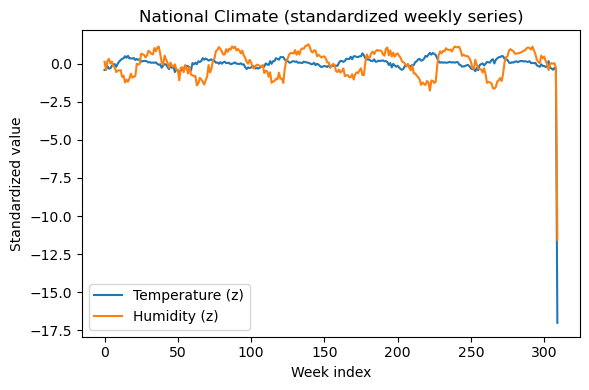

In [6]:
plt.figure(figsize=(6,4))
plt.plot(nat["t2m_z"].values, label="Temperature (z)")
plt.plot(nat["rh_z"].values, label="Humidity (z)")
plt.title("National Climate (standardized weekly series)")
plt.xlabel("Week index")
plt.ylabel("Standardized value")
plt.legend()
plt.tight_layout()
plt.show()


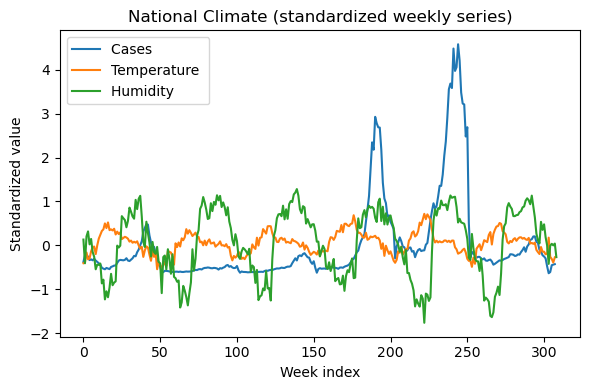

In [7]:
plt.figure(figsize=(6,4))

# Slice the data to include indices 0 up to 300
plt.plot(nat["cases_z"].values[:308], label="Cases ")
plt.plot(nat["t2m_z"].values[:308], label="Temperature ")
plt.plot(nat["rh_z"].values[:-1], label="Humidity ")

plt.title("National Climate (standardized weekly series)")
plt.xlabel("Week index")
plt.ylabel("Standardized value")

# Set x-axis limit to 300
#plt.xlim(0, 300)

#plt.legend()
plt.legend(loc="upper left") # Explicitly set to best--upper,lower, center
plt.tight_layout()
plt.show()





## Interpretation of the National Standardized Dengue–Climate Time Series

The Figure presents standardized weekly time series of confirmed dengue cases, mean temperature, and mean relative humidity aggregated nationally from 2020 to 2026.

All variables were standardized using z-transformation:

$$
z = \frac{x - \mu}{\sigma}
$$

where $(x)$ is the observed weekly value, $(\mu)$ is the mean of the series, and $(\sigma)$ is its standard deviation. Standardization removes unit differences and rescales each variable to have mean zero and variance one, enabling direct visual comparison of temporal co-movement between variables measured on different scales.

The standardized series reveal clear seasonal oscillations in both climatic variables and dengue incidence. Peaks in dengue cases tend to follow periods of elevated temperature and relative humidity. The large epidemic wave observed during $2023–2024$ is visually preceded by sustained above-average temperature conditions. Humidity exhibits seasonal fluctuations that partially align with dengue peaks, although the relationship appears less direct than for temperature.

The pronounced downward spike at the end of the series reflects incomplete data coverage for the most recent weeks, where dengue case counts are still accumulating. This boundary artifact does not represent a true epidemiological decline and will be addressed in modeling by restricting analyses to complete epidemiological weeks.

Importantly, this figure is descriptive and does not imply causality. It serves to illustrate temporal alignment patterns and motivate formal lagged regression modeling in the subsequent analysis.



In [8]:
#lag correlation
cors = []
for L in range(0, 7):
    tmp = panel.dropna(subset=[f"t2m_lag{L}"])
    natL = tmp.groupby(["iso_year","iso_week"], as_index=False).agg(
        cases=("total_cases","sum"),
        t=("t2m_lag"+str(L), "mean"),
    )
    cor = natL["cases"].corr(natL["t"])
    cors.append((L, cor))

print("Temperature lag correlations (national):")
print(cors)


Temperature lag correlations (national):
[(0, np.float64(0.0171505358991972)), (1, np.float64(0.05215584263981094)), (2, np.float64(0.12215278877336734)), (3, np.float64(0.19164757020413653)), (4, np.float64(0.24819312607076474)), (5, np.float64(0.2915404929259347)), (6, np.float64(0.3234572860694906))]




## Interpretation of Temperature Lag Correlation

The  lag correlation analysis indicates that the association between weekly mean temperature and confirmed dengue incidence strengthens progressively with increasing lag length, reaching its highest value at a lag of approximately six weeks. While these correlations are descriptive and do not adjust for seasonality, spatial heterogeneity, or population size, the monotonic increase in correlation across lags is consistent with known biological mechanisms underlying dengue transmission dynamics.

Dengue transmission involves multiple temperature-sensitive processes. First, mosquito development from egg to adult is strongly influenced by ambient temperature, with warmer conditions accelerating larval maturation. Second, the extrinsic incubation period, defined as the time required for viral replication within the mosquito before it becomes infectious, shortens at higher temperatures. Third, the intrinsic incubation period in humans introduces additional delay between infection and symptom onset. The combined duration of vector development, viral amplification within the mosquito, and human incubation commonly spans several weeks. Experimental and field studies have shown that these processes typically generate effective transmission lags in the range of approximately three to six weeks.

Since the correlation increases steadily, this suggests that temperature effects are delayed rather than immediate. Therefore, the observed increase in correlation up to a six-week lag  motivate the inclusion of distributed lag structures in subsequent regression modeling



In [9]:
#save 
out_panel_path = os.path.join(base_dir, "panel_dengue_climate_nasa_2020_2026.csv")
#panel.to_csv(out_panel_path, index=False)
print("Saved:", out_panel_path)


Saved: C:\Users\Tosin\Downloads\BMC\panel_dengue_climate_nasa_2020_2026.csv


In [13]:
nat

,iso_year,iso_week,cases,t2m,rh,cases_z,t2m_z,rh_z
0,2020,1,893,19.134936,69.842434,-0.375701,-0.405241,0.133108
1,2020,2,1426,19.303669,62.509373,-0.221866,-0.385992,-0.406890
2,2020,3,1391,21.292171,70.812568,-0.231968,-0.159144,0.204548
3,2020,4,1318,19.909580,72.365109,-0.253037,-0.316869,0.318875
4,2020,5,1036,20.074135,68.357738,-0.334428,-0.298097,0.023777
...,...,...,...,...,...,...,...,...
305,2026,2,632,19.982143,68.528514,-0.451031,-0.308592,0.036353
306,2026,3,681,19.272564,68.039931,-0.436889,-0.389540,0.000374
307,2026,4,717,20.307463,68.599963,-0.426498,-0.271479,0.041614
308,2026,5,669,19.080910,64.415574,-0.440352,-0.411404,-0.266520


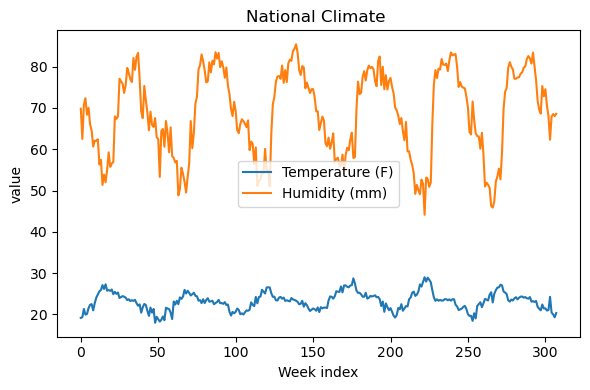

In [10]:
plt.figure(figsize=(6,4))
#plt.plot(nat["cases"].values, label="Cases (z)")
plt.plot(nat["t2m"].values[:308], label="Temperature (F)")
plt.plot(nat["rh"].values[:308], label="Humidity (mm)")
plt.title("National Climate ")
plt.xlabel("Week index")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

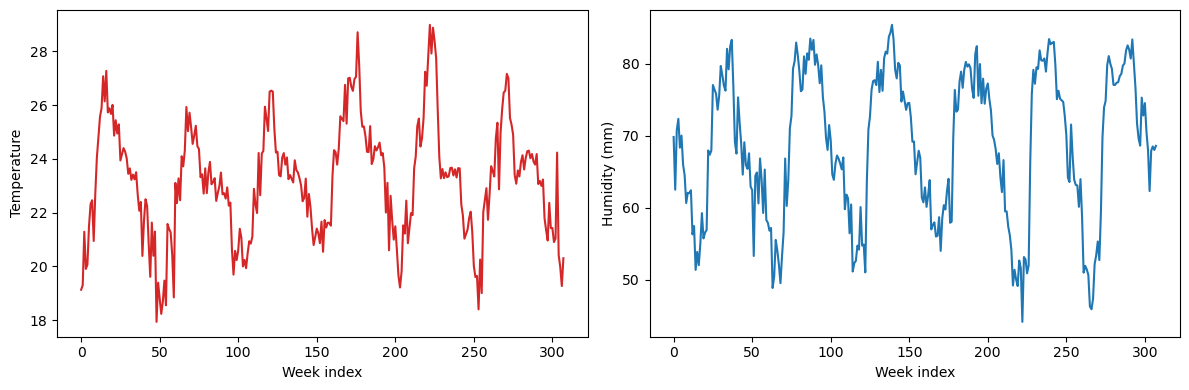

In [13]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: Temperature
ax1.plot(nat["t2m"].values[:308], label="Temperature (F)", color="tab:red")
#ax1.set_title("National Temperature")
ax1.set_xlabel("Week index")
ax1.set_ylabel("Temperature")
#ax1.set_xlim(0, 300)
#ax1.legend()
#ax1.legend(loc="best") # Explicitly set to best

# Second subplot: Humidity
ax2.plot(nat["rh"].values[:308], label="Humidity (mm)", color="tab:blue")
#ax2.set_title("National Humidity")
ax2.set_xlabel("Week index")
ax2.set_ylabel("Humidity (mm)")
#ax2.set_xlim(0, 300)
#ax2.legend()
#ax2.legend(loc="upper left") # Explicitly set to best

plt.tight_layout()
plt.show()


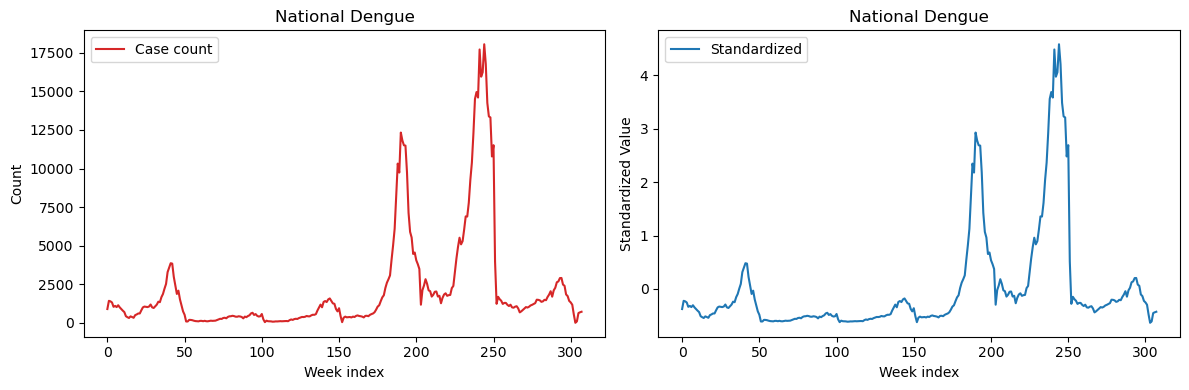

In [14]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First subplot: Temperature
ax1.plot(nat["cases"].values[:308], label="Case count", color="tab:red")
ax1.set_title("National Dengue")
ax1.set_xlabel("Week index")
ax1.set_ylabel("Count")
#ax1.set_xlim(0, 308)
ax1.legend()
ax1.legend(loc="best") # Explicitly set to best

# Second subplot: Humidity
ax2.plot(nat["cases_z"].values[:308], label="Standardized", color="tab:blue")
ax2.set_title("National Dengue")
ax2.set_xlabel("Week index")
ax2.set_ylabel("Standardized Value")
#ax2.set_xlim(0, 300)
ax2.legend()
ax2.legend(loc="upper left") # Explicitly set to best

plt.tight_layout()
plt.show()




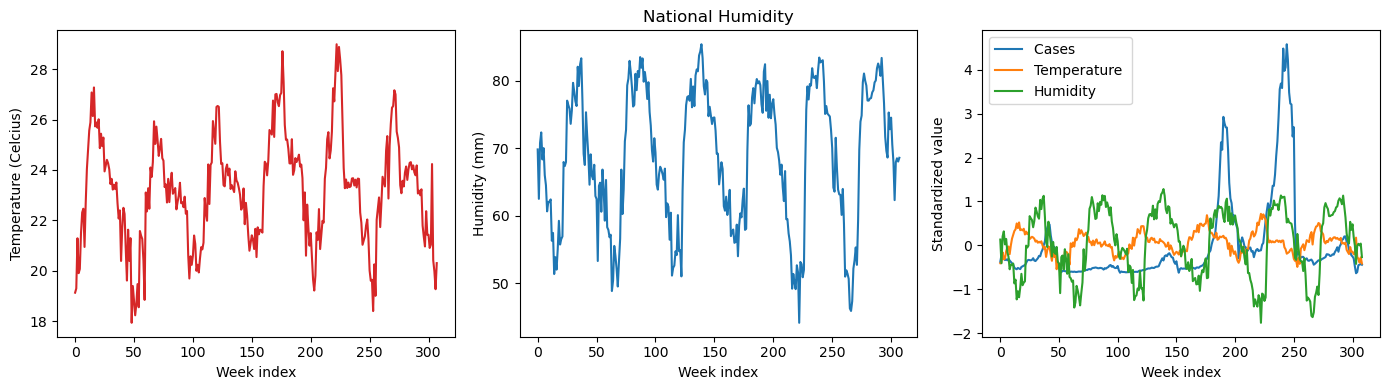

In [16]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# First subplot: Temperature
ax1.plot(nat["t2m"].values[:308], label="Temperature (F)", color="tab:red")
#ax1.set_title("National Temperature")
ax1.set_xlabel("Week index")
ax1.set_ylabel("Temperature (Celcius)")
#ax1.set_xlim(0, 300)
#ax1.legend()
#ax1.legend(loc="best") # Explicitly set to best

# Second subplot: Humidity
ax2.plot(nat["rh"].values[:308], label="Humidity (mm)", color="tab:blue")
ax2.set_title("National Humidity")
ax2.set_xlabel("Week index")
ax2.set_ylabel("Humidity (mm)")
#ax2.set_xlim(0, 300)
#ax2.legend()
#ax2.legend(loc="upper left") # Explicitly set to best

ax3.plot(nat["cases_z"].values[:-1], label="Cases ")
ax3.plot(nat["t2m_z"].values[:-1], label="Temperature ")
ax3.plot(nat["rh_z"].values[:-1], label="Humidity")

#ax3.set_title("National Climate")
ax3.set_xlabel("Week index")
ax3.set_ylabel("Standardized value")
ax3.legend(loc="upper left") # Explicitly set to best--upper,lower, center
plt.tight_layout()
plt.show()


## General
Although the lagged correlation analysis provides preliminary evidence of delayed associations between temperature and dengue incidence, simple Pearson correlations are insufficient for causal inference or quantitative risk estimation. Correlation analysis does not account for the discrete and overdispersed nature of dengue case counts, ignores population denominators, and fails to control for unobserved spatial heterogeneity across municipalities. Moreover, correlations cannot simultaneously evaluate multiple lag structures or disentangle short-term weather variability from long-term seasonal trends. Dengue incidence data are count outcomes that typically exhibit overdispersion relative to a Poisson process due to clustering and heterogeneous transmission intensity. For these reasons, a negative binomial regression framework is more appropriate. Incorporating distributed lag terms within this model allows estimation of delayed climate effects across multiple weeks, while mixed effects can account for municipality-level random variation. This approach provides statistically robust effect estimates and enables inference on how weekly climate variability contributes to spatially heterogeneous dengue risk.